In [1]:
import numpy as np
import pandas as pd
import sys
sys.path.append("..")
from utils import bootcampviztools as bt
import seaborn as sns
import matplotlib.pyplot as plt

# Problema de negocio

El objetivo de este proyecto es desarrollar un modelo de Machine Learning capaz de predecir si un paciente ha sufrido un ataque cardíaco (`HadHeartAttack`) en función de variables demográficas, hábitos de salud y condiciones médicas.

Este problema es un problema de clasificación binaria, donde:

- Clase 0: el paciente no ha sufrido un ataque cardíaco
- Clase 1: el paciente ha sufrido un ataque cardíaco

Este modelo podría utilizarse como herramienta de apoyo en entornos clínicos para identificar pacientes con alto riesgo cardiovascular y facilitar la toma de decisiones médicas preventivas.

In [2]:
df = pd.read_csv ("../data/heart_2022_with_nans.csv")
df.head(10)

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,...,NaN,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
1,Alabama,Female,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,...,1.60,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
2,Alabama,Female,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,...,1.57,63.50,25.61,No,No,No,No,NaN,No,Yes
3,Alabama,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,...,1.65,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Alabama,Female,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,No,...,1.57,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No
5,Alabama,Male,Poor,1.0,0.0,Within past year (anytime less than 12 months ...,No,7.0,NaN,Yes,...,1.80,84.82,26.08,No,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No
6,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,...,1.65,62.60,22.96,Yes,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
7,Alabama,Female,Good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,...,1.63,73.48,27.81,No,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No
8,Alabama,Female,Good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,6.0,NaN,No,...,1.70,NaN,NaN,No,Yes,No,No,"Yes, received tetanus shot but not sure what type",No,No
9,Alabama,Female,Good,1.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,...,1.68,81.65,29.05,Yes,NaN,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445132 entries, 0 to 445131
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      445132 non-null  object 
 1   Sex                        445132 non-null  object 
 2   GeneralHealth              443934 non-null  object 
 3   PhysicalHealthDays         434205 non-null  float64
 4   MentalHealthDays           436065 non-null  float64
 5   LastCheckupTime            436824 non-null  object 
 6   PhysicalActivities         444039 non-null  object 
 7   SleepHours                 439679 non-null  float64
 8   RemovedTeeth               433772 non-null  object 
 9   HadHeartAttack             442067 non-null  object 
 10  HadAngina                  440727 non-null  object 
 11  HadStroke                  443575 non-null  object 
 12  HadAsthma                  443359 non-null  object 
 13  HadSkinCancer              44

In [4]:
df.describe()

,PhysicalHealthDays,MentalHealthDays,SleepHours,HeightInMeters,WeightInKilograms,BMI
count,434205.000000,436065.000000,439679.000000,416480.000000,403054.000000,396326.000000
mean,4.347919,4.382649,7.022983,1.702691,83.074470,28.529842
std,8.688912,8.387475,1.502425,0.107177,21.448173,6.554889
min,0.000000,0.000000,1.000000,0.910000,22.680000,12.020000
25%,0.000000,0.000000,6.000000,1.630000,68.040000,24.130000
50%,0.000000,0.000000,7.000000,1.700000,80.740000,27.440000
75%,3.000000,5.000000,8.000000,1.780000,95.250000,31.750000
max,30.000000,30.000000,24.000000,2.410000,292.570000,99.640000


- Variables como BMI, WeightInKilograms y PhysicalHealthDays presentan una alta variabilidad.
- La media de SleepHours se sitúa en torno a valores normales, lo que indica que la mayoría de pacientes tienen hábitos de sueño razonables.
- Se detectan posibles valores extremos en variables como BMI y WeightInKilograms, lo que sugiere la presencia de outliers.
- La diferencia entre el count y el número total de observaciones confirma la existencia de valores faltantes en algunas variables.

En general, las variables numéricas presentan rangos coherentes y contienen información relevante para el modelado.

## Análisis de variables

|Columna|Descripción|Tipo|Categorías|
|:-----:|:-----:|:-----:|:-----:|
|State|Estado de residencia de la persona encuestada en USA|Categórica nominal|Estados y territorios de USA|
|Sex|Género de la persona encuestada|Categórica nominal|Female, Male|
|General Health|Estado general de la salud|Categórica ordinal|Poor,Fair,Good,Very good,Excellent|
|Physical Health Days|Días con mala salud física de los últimos 30 días|Numérica discreta|Días(0-30)|
|Mental Health Days|Días con mala salud mental de los últimos 30 días|Numérica discreta|Días(0-30)|
|Last Checkup Time|Tiempo desde el último chequeo|Categórica ordinal|<1 year, 1-2 years, >5 years, Never|
|Physical Activities|Si realiza actividad física o no|Booleana|Yes/No|
|Sleep Hours|Horas de sueño diario|Numérica continua|Horas|
|Removed Teeth|Cantidad de dientes quitados|Categórica ordinal|NaN,1-5,6+,All|
|Had Heart Attack|Si ha sufrido o no un ataque al corazón|Booleana|Yes/No|
|Had Angina|Si ha sufrido una angina de pecho|Booleana|Yes/No|
|Had Stroke|Si ha sufrido un derrame cerebral|Booleana|Yes/No|
|Had Asthma|Si tiene asma o no|Booleana|Yes/No|
|Had Skin Cancer|Si ha sufrido cáncer de piel|Booleana|Yes/No|
|Had COPD|Si tiene EPOC|Booleana|Yes/No|
|Had Depressive Disorder|Si ha sido diagnosticado de trastorno depresivo|Booleana|Yes/No|
|Had Kidney Disease|Si tiene problemas renales|Booleana|Yes/No|
|Had Arthritis|Diagnóstico de artritis|Booleana|Yes/No|
|Had Diabetes|Diagnóstico de diabetes|Categórica nominal|Yes, No, Borderline, During Pregnancy|
|Deaf Or Hard Of Hearing|Problemas auditivos|Booleana|Yes/No|
|Blind Or Vision Difficulty|Problemas visuales|Booleana|Yes/No|
|Difficulty Concentrating|Dificultad para concentrarse|Booleana|Yes/No|
|Difficulty Walking|Dificultad para andar|Booleana|Yes/No|
|Difficulty Dressing Bathing|Dificultad para vestirse o bañarse|Booleana|Yes/No|
|Difficulty Errands|Dificultad para realizar recados solo|Booleana|Yes/No|
|Smoker Status|Estado respecto al hábito de fumar|Categórica ordinal|Never, Former, Current (some days), Current (every day)|
|ECigarette Usage|Uso de cigarrillos electrónicos|Categórica ordinal|Never, Former, Current (some days), Current (every day)|
|Chest Scan|Se se ha realizado un escáner torácico|Booleana|Yes/No|
|Race Ethnicity Category|Grupo racial o étnico|Categórica nominal|White, Black, Hispanic, etc.|
|Age Category|Edad de la persona encuestada|Categórica ordinal|Rangos de edad|
|Height In Meters|Altura de la persona encuestada|Numérica continua|Metros|
|Weight In Kilograms|Peso de la persona encuestada|Numérica continua|kg|
|BMI|Índice de Masa Corporal|Numérica continua|kg|
|Alcohol Drinkers|Consumo de alcohol|Booleana|Yes/No|
|HIV Testing|Si se ha realizado el test de VIH|Booleana|Yes/No|
|Flu Vax Last 12|Si se ha puesto la vacuna de la gripe en los últimos 12 meses|Booleana|Yes/No|
|Pneumo Vax Ever|Si le han puesto la vacuna neumocócica alguna vez|Booleana|Yes/No|
|Tetanus Last 10 Tdap|Si le han puesto la vacuna antitetánica (Tdap) en los últimos 10 años|Categórica nominal|Yes, No, Don't know|
|High Risk Last Year|Conductas de alto riesgo durante el último año|Booleana|Yes/No|
|CovidPos|Resultado positivo en una prueba de COVID-19|Categórica nominal|Yes, No, Don't know|

In [5]:
target = "HadHeartAttack"

In [ ]:
df["HadHeartAttack"].value_counts(normalize=True)*100

HadHeartAttack
No     94.320318
Yes     5.679682
Name: proportion, dtype: float64

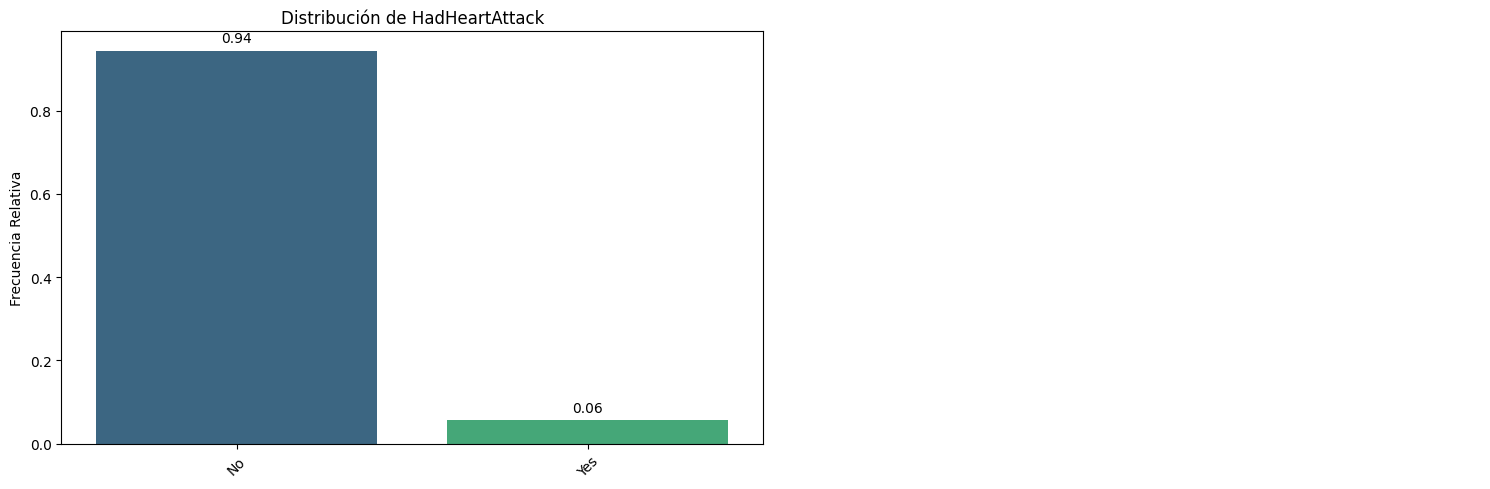

In [7]:
bt.pinta_distribucion_categoricas (df, [target], relativa= True, mostrar_valores=True)

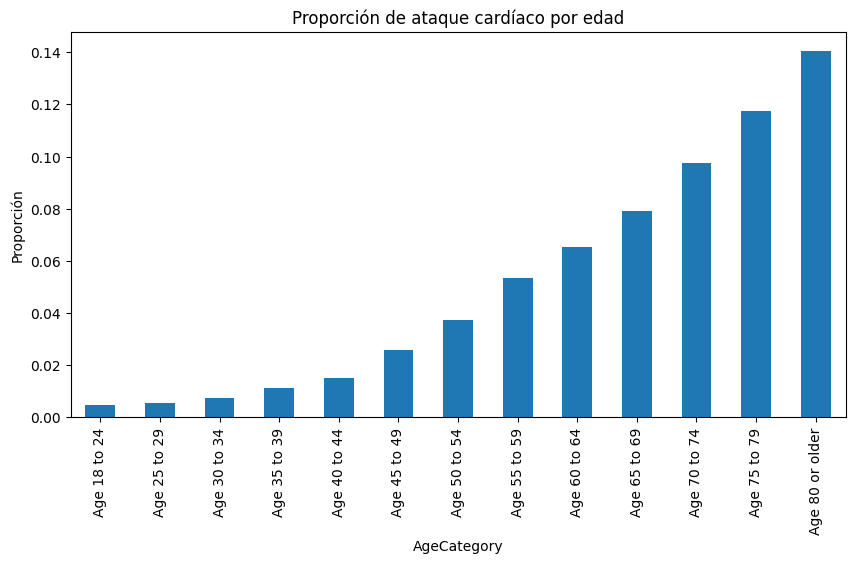

In [8]:
pd.crosstab(df["AgeCategory"], df["HadHeartAttack"], normalize="index")["Yes"].plot(kind="bar", figsize=(10,5))

plt.title("Proporción de ataque cardíaco por edad")
plt.ylabel("Proporción")
plt.show()

### Análisis del target

- La variable objetivo es HadHeartAttack, que indica si el paciente ha sufrido un ataque cardíaco.

- Se observa un desbalance en las clases, con una proporción menor de pacientes que han sufrido un ataque cardíaco.

- El riesgo aumenta significativamente con la edad, lo que indica que AgeCategory es un predictor relevante.

In [9]:
cardinalidad_df = df.nunique().reset_index()

cardinalidad_df.columns = ["Columna", "Cardinalidad"]

cardinalidad_df["Cardinalidad (%)"] = (
    cardinalidad_df["Cardinalidad"] / len(df)
) * 100

cardinalidad_df = cardinalidad_df.sort_values("Cardinalidad", ascending=False)

cardinalidad_df

,Columna,Cardinalidad,Cardinalidad (%)
32,BMI,3985,0.895240
31,WeightInKilograms,599,0.134567
30,HeightInMeters,109,0.024487
0,State,54,0.012131
3,PhysicalHealthDays,31,0.006964
4,MentalHealthDays,31,0.006964
7,SleepHours,24,0.005392
29,AgeCategory,13,0.002920
2,GeneralHealth,5,0.001123
28,RaceEthnicityCategory,5,0.001123


In [10]:
print (df.duplicated().sum())

157


In [11]:
df = df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.shape

(444975, 40)

## Tratamiento de duplicados

- Se han detectado 157 registros duplicados en el dataset.

- Estos registros han sido eliminados para evitar que el modelo aprenda patrones repetidos que puedan sesgar el entrenamiento.

In [14]:
summary_df = pd.DataFrame({
    "Variable": df.columns,
    "Tipo": df.dtypes.values,
    "Missing (%)": (df.isna().mean() * 100).values,
    "Valores únicos": df.nunique().values,
    "Cardinalidad (%)": ((df.nunique() / len(df)) * 100).values
})

summary_df = summary_df.sort_values("Missing (%)", ascending=False)

summary_df

,Variable,Tipo,Missing (%),Valores únicos,Cardinalidad (%)
37,TetanusLast10Tdap,object,18.511152,4,0.000899
36,PneumoVaxEver,object,17.280521,2,0.000449
34,HIVTesting,object,14.828024,2,0.000449
27,ChestScan,object,12.562504,2,0.000449
39,CovidPos,object,11.375471,3,0.000674
38,HighRiskLastYear,object,11.343783,2,0.000449
32,BMI,float64,10.935221,3985,0.895556
35,FluVaxLast12,object,10.556773,2,0.000449
33,AlcoholDrinkers,object,10.433845,2,0.000449
31,WeightInKilograms,float64,9.423226,599,0.134614


### Tabla resumen

- Se ha creado una tabla resumen con el tipo de variable, porcentaje de valores faltantes y cardinalidad.

In [15]:
porcentaje_nulos = (df.isna().mean() * 100).sort_values(ascending=False)

porcentaje_nulos

TetanusLast10Tdap            18.511152
PneumoVaxEver                17.280521
HIVTesting                   14.828024
ChestScan                    12.562504
CovidPos                     11.375471
HighRiskLastYear             11.343783
BMI                          10.935221
FluVaxLast12                 10.556773
AlcoholDrinkers              10.433845
WeightInKilograms             9.423226
ECigaretteUsage               7.981123
SmokerStatus                  7.936626
HeightInMeters                6.405978
DifficultyErrands             5.733131
DifficultyConcentrating       5.414911
DifficultyWalking             5.363672
DifficultyDressingBathing     5.341873
BlindOrVisionDifficulty       4.813529
DeafOrHardOfHearing           4.607450
RaceEthnicityCategory         3.157031
RemovedTeeth                  2.551829
PhysicalHealthDays            2.454520
AgeCategory                   2.038092
MentalHealthDays              2.036519
LastCheckupTime               1.865498
SleepHours               

In [16]:
cols_to_drop = df.columns[df.isna().mean() > 0.5].tolist()

print(f"Se eliminarán {len(cols_to_drop)} columnas:")
for col in cols_to_drop:
    print("-", col)

df.drop(columns=cols_to_drop, inplace=True)

Se eliminarán 0 columnas:


## Eliminación de columnas con alto porcentaje de valores faltantes

- Se evaluó el porcentaje de valores faltantes en cada columna.

- No se encontraron columnas con más del 50% de valores nulos, por lo que no fue necesario eliminar ninguna columna en este paso.

In [17]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include="object").columns

In [18]:
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

In [19]:
df.isna().sum()

State                        0
Sex                          0
GeneralHealth                0
PhysicalHealthDays           0
MentalHealthDays             0
LastCheckupTime              0
PhysicalActivities           0
SleepHours                   0
RemovedTeeth                 0
HadHeartAttack               0
HadAngina                    0
HadStroke                    0
HadAsthma                    0
HadSkinCancer                0
HadCOPD                      0
HadDepressiveDisorder        0
HadKidneyDisease             0
HadArthritis                 0
HadDiabetes                  0
DeafOrHardOfHearing          0
BlindOrVisionDifficulty      0
DifficultyConcentrating      0
DifficultyWalking            0
DifficultyDressingBathing    0
DifficultyErrands            0
SmokerStatus                 0
ECigaretteUsage              0
ChestScan                    0
RaceEthnicityCategory        0
AgeCategory                  0
HeightInMeters               0
WeightInKilograms            0
BMI     

### Tratamiento de valores faltantes

- Se imputaron los valores faltantes para evitar la pérdida de datos.

- Las variables numéricas se imputaron con la mediana y las variables categóricas con la moda.

- Este método permite conservar el tamaño del dataset y evitar introducir sesgos significativos.

In [20]:
df["HadHeartAttack_num"] = df["HadHeartAttack"].map({"No": 0, "Yes": 1}) #Convertimos el target a numérico para hacer la correlación

In [21]:
numerical_cols = df.select_dtypes(include=["int64","float64"]).columns

correlacion_target = df[numerical_cols].corr()["HadHeartAttack_num"].sort_values(ascending=False)

correlacion_target

HadHeartAttack_num    1.000000
PhysicalHealthDays    0.136109
WeightInKilograms     0.036447
BMI                   0.029799
MentalHealthDays      0.027850
HeightInMeters        0.021105
SleepHours            0.003808
Name: HadHeartAttack_num, dtype: float64

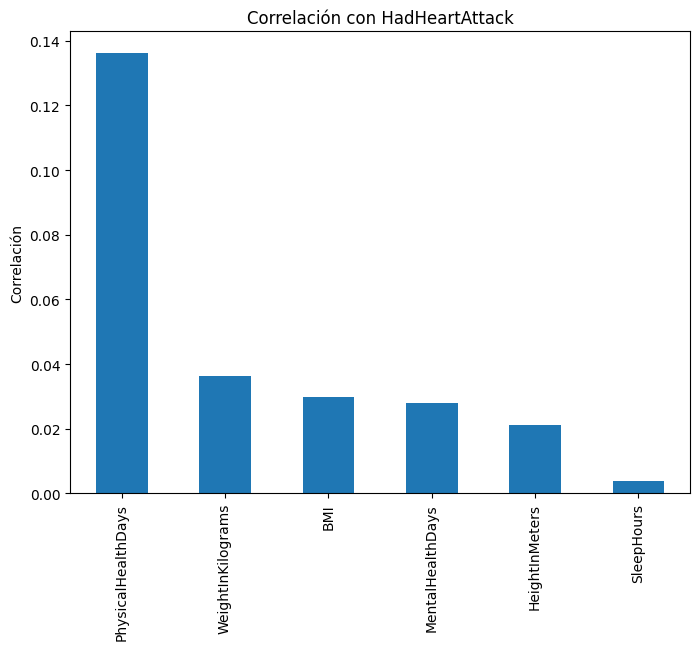

In [22]:
plt.figure(figsize=(8,6))
correlacion_target.drop("HadHeartAttack_num").plot(kind="bar")
plt.title("Correlación con HadHeartAttack")
plt.ylabel("Correlación")
plt.show()

### Análisis de correlación con el target

- Se analizó la correlación entre las variables numéricas y la variable objetivo HadHeartAttack.

- Variables como PhysicalHealthDays, WeightInKilograms y BMI muestran una alta correlación en comparación con las otras variables (MentalHealthDays, HeightInMeters y SleepHours).

- Las variables con correlación más baja que hemos mencionado anteriormente podrían eliminarse más adelante.

In [23]:
categorical_cols = df.select_dtypes(include="object").columns

resultados = []

for col in categorical_cols:
    
    if col != "HadHeartAttack":
        
        # calcular riesgo por categoría
        risk = pd.crosstab(df[col], df["HadHeartAttack"], normalize="index")["Yes"]
        
        # calcular diferencia de riesgo
        min_risk = risk.min()
        max_risk = risk.max()
        difference = max_risk - min_risk
        
        resultados.append({
            "Variable": col,
            "Min Risk": min_risk,
            "Max Risk": max_risk,
            "Diferencia": difference
        })

importance_df = pd.DataFrame(resultados)

importance_df = importance_df.sort_values("Diferencia", ascending=False)

importance_df

,Variable,Min Risk,Max Risk,Diferencia
6,HadAngina,0.031547,0.448495,0.416948
7,HadStroke,0.047381,0.256576,0.209194
2,GeneralHealth,0.015274,0.210780,0.195506
5,RemovedTeeth,0.031139,0.170668,0.139529
25,AgeCategory,0.004529,0.138597,0.134068
12,HadKidneyDisease,0.050650,0.177160,0.126510
10,HadCOPD,0.046831,0.166564,0.119732
14,HadDiabetes,0.028936,0.141640,0.112704
19,DifficultyDressingBathing,0.052506,0.156248,0.103742
18,DifficultyWalking,0.040757,0.143172,0.102415


### Relación entre variables categóricas y el target

- Se ha analizado la relación entre las variables categóricas y la variable objetivo HadHeartAttack.

- Se ha utilizado la diferencia entre el riesgo máximo y mínimo como medida de importancia.

- Variables como HadAngina, HadStroke, GeneralHealth y AgeCategory muestran mayor relación con el riesgo de ataque cardíaco. Estas variables se mantendrán para el modelado.

- Variables con menor diferencia presentan menor relevancia y pueden eliminarse, como por ejemplo: LastCheckUpTime, HadSkinCancer, PhysicalActivities y State.

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

* Si la diferencia entre Min Risk y Max Risk es de 0.10: **mantener**.

* Si la diferencia entre Min Risk y Max Risk es de 0.05–0.10: **mantener**.

* Si la diferencia entre Min Risk y Max Risk es de 0.03–0.05: **evaluar si se elimina o no**.

* Si la diferencia entre Min Risk y Max Risk es de < 0.03: **eliminar**.


In [24]:
df["HadHeartAttack_num"].isna().sum()

np.int64(0)

In [25]:
df["HadHeartAttack"].unique()

array(['No', 'Yes'], dtype=object)

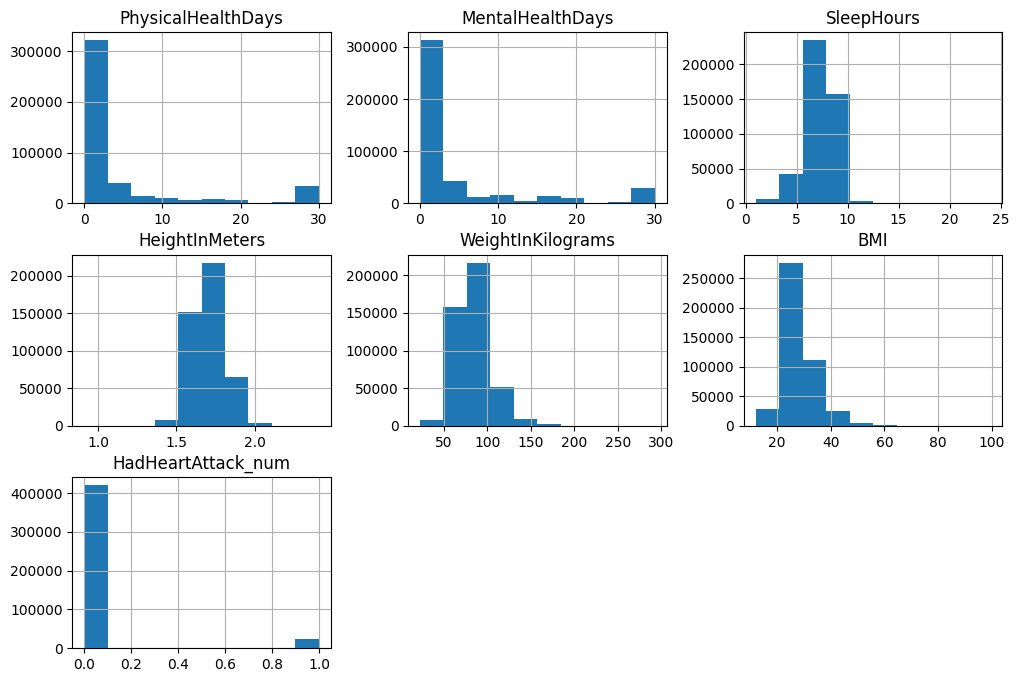

In [26]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[numerical_cols].hist(figsize=(12,8))
plt.show()

### Conclusiones Histograma

- Se observa que variables como BMI y WeightInKilograms presentan distribuciones ligeramente asimétricas hacia la derecha, lo cual es esperable en variables relacionadas con el peso corporal.

- Variables como SleepHours presentan una distribución más centrada, con la mayoría de valores concentrados entre 6 y 8 horas.

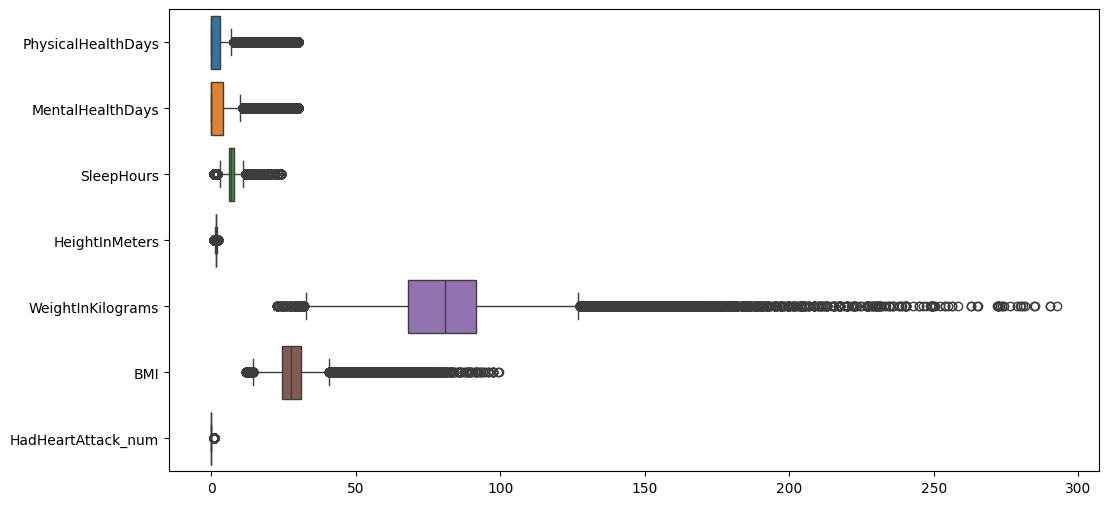

In [27]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numerical_cols], orient="h")
plt.show()

### Conclusiones Boxplot

- Se observan algunos outliers en variables como BMI y WeightInKilograms, lo cual es esperable en datasets de salud debido a la variabilidad natural entre individuos. Estos valores extremos no parecen ser errores, sino observaciones válidas, por lo que no se eliminarán en esta etapa.

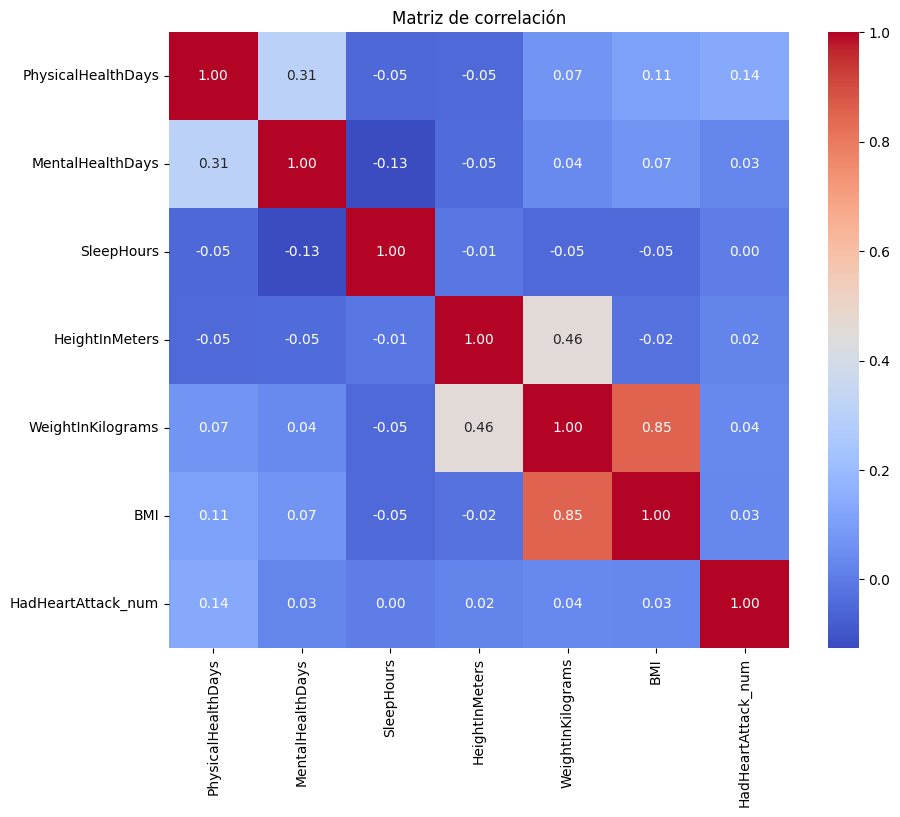

In [28]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación")
plt.show()

### Conclusiones Heatmap

- El heatmap muestra la correlación entre las variables numéricas del dataset.

- Se observa que algunas variables presentan correlación moderada con el target HadHeartAttack, especialmente PhysicalHealthDays, lo que sugiere que un mayor número de días con mala salud física se asocia con mayor riesgo de enfermedad cardíaca.

- También se observa correlación entre variables físicas como BMI, WeightInKilograms y HeightInMeters, lo cual es esperable debido a su relación fisiológica.

## Conclusión del análisis exploratorio

- Se ha realizado un análisis exploratorio completo del dataset y se ha observado un desbalance en la variable objetivo (HadHeartAttack).

- Las variables numéricas presentan correlaciones moderadas con el target.

- Las variables categóricas como HadAngina, HadStroke, GeneralHealth y AgeCategory muestran fuerte asociación con el riesgo de ataque cardíaco. Estas variables se identifican como los predictores más relevantes para el modelo.

- Variables con menor asociación presentan menor capacidad predictiva y pueden eliminarse en etapas posteriores.

#### 1.1 Eliminar columnas categóricas irrelevantes
- Usaré la tabla importance_df que Judit creó
- Esta tabla tiene:
    - Variable: el nombre de la columna categórica
    - Diferencia: diferencia entre el riesgo máximo y mínimo de ataque cardíaco por categoría
- Eliminaré todas las columnas donde Diferencia < 0.03

In [29]:
# Definir el umbral para considerar una columna irrelevante
umbral_cat = 0.03

# Seleccionar las columnas categóricas irrelevantes a eliminar
cols_cat_irrelevantes = importance_df[importance_df["Diferencia"] < umbral_cat]["Variable"].tolist()

# Mostrar cuáles se eliminarán
print("Columnas categóricas irrelevantes que se eliminarán:")
for col in cols_cat_irrelevantes:
    print(col)

# Eliminar estas columnas del df
df.drop(columns=cols_cat_irrelevantes, inplace=True)

Columnas categóricas irrelevantes que se eliminarán:
ECigaretteUsage
TetanusLast10Tdap
HighRiskLastYear
RaceEthnicityCategory
FluVaxLast12
HadAsthma
HadDepressiveDisorder
HIVTesting


#### 1.2 Eliminar columnas numéricas irrelevantes
- Usaré la tabla correlacion_target que Judit creó
- La correlación mide qué tan linealmente relacionadas están dos variables:
    - +1: relación positiva fuerte
    - -1: relación negativa fuerte
    - 0: casi no hay relación
- Si la correlación está cerca de 0, significa que esa variable casi no ayuda a predecir el ataque cardíaco

In [30]:
# Excluir el target de la lista de correlaciones
cols_num_corr = correlacion_target.drop("HadHeartAttack_num")

# Definir el umbral para considerar una columna irrelevante
umbral_num = 0.03

# Seleccionar las columnas numéricas irrelevantes a eliminar
cols_num_irrelevantes = cols_num_corr[abs(cols_num_corr) < umbral_num].index.tolist()

# Mostrar cuáles se eliminarán
print("Columnas numéricas irrelevantes que se eliminarán:")
for col in cols_num_irrelevantes:
    print(col)

# Eliminar estas columnas del df
df.drop(columns=cols_num_irrelevantes, inplace=True)

Columnas numéricas irrelevantes que se eliminarán:
BMI
MentalHealthDays
HeightInMeters
SleepHours


#### 2.1 Detectar valores imposibles 
##### Análisis de los valores
|Columna|Min|Max|Observaciones|
|---|---|---|---|
|PhysicalHealthDays|0|30|Está dentro del rango válido (0-30 días). Ningún valor imposible.|
|WeightInKilograms|22.68|292.57|Peso <30 kg es muy bajo, y >200-250 kg es muy alto. Hay que revisar valores extremos.|

##### Conclusión
- PhysicalHealthDays: no hay valores imposibles
- WeightInKilograms: hay valores muy improbables. Ya veré qué hacer con ellos

#### 2.2 Detecar outliers (IQR + boxplot)
- A diferencia de los valores imposibles, los outliers son valores extremos, pero posibles
- Primero, los detectaré visualmente con boxplots y numéricamente con IQR
    - IQR (Interquartile Range) = Q3 - Q1
        - Límites usuales:
            - Inferior = Q1 - 1.5xIQR
            - Superior = Q3 + 1.5xIQR
        - Todo valor fuera de esos límites = outlier potencial

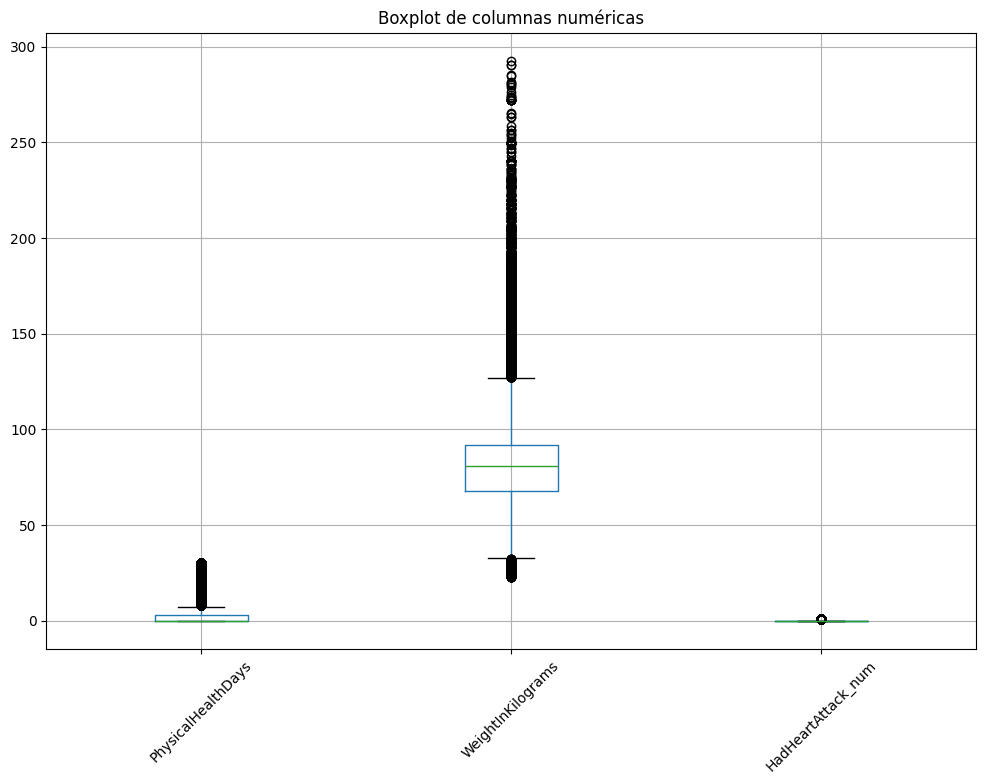

Número de outliers por columna:
PhysicalHealthDays    72268
HadHeartAttack_num    25108
WeightInKilograms     13618
dtype: int64


In [31]:
# Seleccionar solo las columnas numéricas que nos quedamos
cols_num = df.select_dtypes(include=["int64", "float64"]).columns

# Visualizar con boxplots
plt.figure(figsize=(12,8))
df[cols_num].boxplot(rot=45)
plt.title("Boxplot de columnas numéricas")
plt.show()

# Calcular límites IQR
Q1 = df[cols_num].quantile(0.25)
Q3 = df[cols_num].quantile(0.75)
IQR = Q3 - Q1

# Crear un df booleano donde True sea outlier
outliers = (df[cols_num] < (Q1 - 1.5*IQR)) | (df[cols_num] > (Q3 + 1.5*IQR))

# Mostrar cuántos hay por columna
outliers_por_col = outliers.sum().sort_values(ascending=False)
print("Número de outliers por columna:")
print(outliers_por_col)

#### 2.3 Decidir tratamiento
- Probaré 2 opciones y dejaré la que considere que ayuda más al modelo

##### Opción 1 - Parte 1
- Convertiré los valores extremos más improbables en NaNs

In [32]:
# WightInKilograms
# df.loc[(df["WeightInKilograms"] < 30) | (df["WeightInKilograms"] > 250), "WeightInKilograms"] = np.nan

# Mostrar cuántos se convirtieron para verificar
# df["WeightInKilograms"].isna().sum()

##### Opción 1 - Parte 2
- Imputaré los NaNs con la mediana
    - La mediana es el valor del centro real de los datos
    - Como no se ve afectada por valores extremos, puede ser una opción muy estable en datasets de salud

In [33]:
# df["WeightInKilograms"] = df["WeightInKilograms"].fillna(df["WeightInKilograms"].median())

# Verificar que no quedan más NaNs
# df["WeightInKilograms"].isna().sum()

##### Opción 2
- Usaré capping
    - Capping significa limitar los valores extremos de una variable
    - Esto ayuda al modelo porque no se ve afectado por valores raros
    - Ejemplo visual:
        - Tengo pesos de personas, y algunos son extremadamente altos o bajos
        - No quiero borrarlos (porque podrían ser reales), pero tampoco quiero que me estropeen el modelo
        - Capping hace que:
        - Todo valor menor que el percentil 1 se reemplace por el valor del percentil 1
        - Todo valor mayor que el percentil 99 se reemplace por el valor del percentil 99
         Los valores extremos se "aplacaron/suavizaron" pero no se eliminaron

In [34]:
# Seleccionar la columna
col = "WeightInKilograms"

# Calcular percentiles 1 y 99
lower = df[col].quantile(0.01)
upper = df[col].quantile(0.99)

# Mostrarlos
print(f"Percentil 1: {lower:.2f}")
print(f"Percentil 99: {upper:.2f}")

# Aplicar capping
df[col] = np.where(df[col] < lower, lower, df[col])
df[col] = np.where(df[col] > upper, upper, df[col])

# Mostrar mínimo y máximo tras capping para verificar
print(f"Nuevo mínimo: {df[col].min():.2f}")
print(f"Nuevo máximo: {df[col].max():.2f}")

Percentil 1: 47.17
Percentil 99: 145.15
Nuevo mínimo: 47.17
Nuevo máximo: 145.15


#### Reflexiones sobre la Opción 1 y 2
##### Por qué usamos percentiles para capping?
- Los percentiles dividen los datos en 100 partes iguales
- El percentil 1 significa "el 1% más bajo de los datos" y el 99 "el 1% más alto"
- Al usar percentil 1 y 99 como límites:
    - Aplanamos/suavizamos solo los valores más extremos
    - No tocamos la gran mayoría de los datos, que es donde está la información real
- Ejemplo visual: 
    - Peso (kg): 30, 50, 60, 70, 200, 300  
    - Percentil 1 ≈ 35  
    - Es decir, todo lo <35 pasa a 35  
    - Percentil 99 ≈ 210  
    - Es decir, todo lo >210 pasa a 210  
    - Tras capping: 35, 50, 60, 70, 200, 210  
- Solo los extremos cambian, todo el resto queda igual

##### Por qué me decanto por el capping? Por qué es mejor que la mediana en este caso?
- La mediana reempaza todos los extremos por un único número
- Se pierde variabilidad
- Útil para imputación de NaNs, no para valores extremos posibles en la realidad
- Ejemplo visual: 
    - Peso (kg): 30, 50, 60, 70, 200, 300  
    - Mediana = 65  
    - Tras mediana: 65, 50, 60, 70, 65, 65  

## 1. Limpieza de datos y control de fuga de información

En esta sección se eliminan filas duplicadas asegurando que los valores NaN se traten como equivalentes, evitando así que registros idénticos puedan aparecer tanto en train como en test.

Se realiza posteriormente una división estratificada (stratify=y) para mantener la proporción de la variable objetivo en ambos conjuntos.

La comprobación final confirma que no existen filas compartidas entre train y test, eliminando cualquier riesgo de data leakage.

In [35]:
df_clean = df.drop_duplicates()

df_full = df_clean.copy()

# Tratar NaN como iguales para eliminar duplicados
df_full_temp = df_full.fillna('__NaN__')
df_final_temp = df_full_temp.drop_duplicates(keep='first')
df_final = df_full.loc[df_final_temp.index].copy()  # Recuperar NaN reales por índice

print(f"Filas eliminadas finalmente: {len(df_full) - len(df_final)}")

# Separar features y target
X = df_final.drop(columns=['HadHeartAttack', 'HadHeartAttack_num'])
y = df_final['HadHeartAttack_num']

# Resetear índice para que sea limpio
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

# Split limpio
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Verificar duplicados entre train y test usando índices originales
train_idx = set(X_train.index)
test_idx = set(X_test.index)
shared = train_idx & test_idx
print(f"Filas idénticas tras eliminación definitiva: {len(shared)}")

Filas eliminadas finalmente: 0
Filas idénticas tras eliminación definitiva: 0


In [36]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

## 2. Preprocesamiento y definición del modelo baseline

Se construye un **ColumnTransformer** para aplicar:

- Imputación por mediana y escalado en variables numéricas.
- Imputación por moda y codificación One-Hot en variables categóricas.

Este preprocesamiento se integra dentro de un **Pipeline**, garantizando que todas las transformaciones se apliquen correctamente dentro de validación cruzada y evitando fugas de información.

Como modelo baseline se utiliza Logistic Regression con **class_weight="balanced"** debido al desbalanceo de clases.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Detectar columnas automáticamente
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

# Preprocesamiento separado
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

# Pipeline completo
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

In [38]:
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [39]:
y_pred_base = baseline_model.predict(X_test)
y_prob_base = baseline_model.predict_proba(X_test)[:, 1]

print("=== Logistic Regression (Baseline) ===")
print(classification_report(y_test, y_pred_base))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_base))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_base))

=== Logistic Regression (Baseline) ===
              precision    recall  f1-score   support

           0       0.98      0.83      0.90     82711
           1       0.22      0.77      0.34      5021

    accuracy                           0.83     87732
   macro avg       0.60      0.80      0.62     87732
weighted avg       0.94      0.83      0.87     87732

ROC-AUC: 0.8829208699458214
Confusion Matrix:
[[68891 13820]
 [ 1169  3852]]


### Resultados del modelo baseline

El modelo baseline muestra un ROC-AUC de aproximadamente 0.88, indicando una buena capacidad discriminativa.

Se observa un recall alto para la clase positiva (infarto), lo cual es deseable en un problema médico, aunque con una precisión baja debido al desbalanceo del dataset.

Este modelo sirve como referencia para comparar modelos más complejos.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [41]:
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     82711
           1       0.57      0.19      0.29      5021

    accuracy                           0.95     87732
   macro avg       0.76      0.59      0.63     87732
weighted avg       0.93      0.95      0.93     87732

ROC-AUC: 0.8641189852542548
Confusion Matrix:
[[81987   724]
 [ 4062   959]]


### Resultados Random Forest

Random Forest mejora la precisión general y la exactitud global, pero reduce considerablemente el recall en la clase minoritaria.

Aunque mantiene un buen ROC-AUC, su comportamiento es más conservador en la detección de casos positivos.

In [42]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print("=== Gradient Boosting ===")
print(classification_report(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     82711
           1       0.59      0.22      0.32      5021

    accuracy                           0.95     87732
   macro avg       0.77      0.60      0.65     87732
weighted avg       0.93      0.95      0.93     87732

ROC-AUC: 0.8836377921342277
Confusion Matrix:
[[81938   773]
 [ 3926  1095]]


### Gradient Boosting

El modelo Gradient Boosting obtiene un ROC-AUC de 0.884, mostrando una ligera mejora respecto al baseline y al Random Forest.

En términos de clasificación, mejora ligeramente la detección de la clase positiva frente a Random Forest, aunque sigue mostrando un recall moderado para los casos de infarto.

Su rendimiento estable en validación cruzada indica buena capacidad de generalización y ausencia de sobreajuste significativo.

En conjunto, se posiciona como una alternativa sólida y más equilibrada que Random Forest en este problema.

In [43]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     82711
           1       0.59      0.22      0.32      5021

    accuracy                           0.95     87732
   macro avg       0.77      0.60      0.64     87732
weighted avg       0.93      0.95      0.93     87732

ROC-AUC: 0.8842867127606195
Confusion Matrix:
[[81943   768]
 [ 3932  1089]]


### XGBoost

XGBoost obtiene el mejor rendimiento global en términos de ROC-AUC (0.884), siendo el modelo con mayor capacidad discriminativa en el conjunto de test.

Presenta un comportamiento muy similar a Gradient Boosting, pero con una ligera mejora tanto en ROC-AUC como en estabilidad en validación cruzada.

A pesar de su mayor complejidad, la mejora respecto a modelos más simples no es drástica, lo que sugiere que el dataset no presenta una estructura extremadamente no lineal.

No obstante, dado su rendimiento superior y consistencia, XGBoost puede considerarse el mejor modelo candidato desde el punto de vista predictivo.

## 3. Validación cruzada

Se realiza validación cruzada con 5 folds utilizando **ROC-AUC** como métrica principal.

Los resultados muestran estabilidad entre train y test, indicando buena generalización y ausencia de sobreajuste significativo.

XGBoost presenta el mejor promedio en validación cruzada.

In [44]:
from sklearn.model_selection import cross_val_score
import numpy as np

models = {
    "Logistic Regression": baseline_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model
}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    )
    
    print(f"{name} ROC-AUC CV Mean: {np.mean(scores):.4f}")

Logistic Regression ROC-AUC CV Mean: 0.8807
Random Forest ROC-AUC CV Mean: 0.8629
Gradient Boosting ROC-AUC CV Mean: 0.8818
XGBoost ROC-AUC CV Mean: 0.8826


## 4. Optimización de hiperparámetros

Se realiza un **GridSearchCV** sobre Random Forest.

Los mejores parámetros encontrados son:
- max_depth = 15
- n_estimators = 400

Sin embargo, el modelo optimizado no supera a XGBoost en ROC-AUC final.

In [45]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 15, 25]
}

grid_search = GridSearchCV(
    rf_model,
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Mejores parámetros:", grid_search.best_params_)

Mejores parámetros: {'model__max_depth': 15, 'model__n_estimators': 400}


## 5. Comparativa de modelos

La comparativa final basada en ROC-AUC muestra:

1. XGBoost (mejor rendimiento)
2. Gradient Boosting
3. Logistic Regression
4. Random Forest

Las diferencias son moderadas, lo que indica que el dataset es relativamente lineal y que modelos complejos no aportan mejoras drásticas.

In [46]:
results = {
    "Logistic Regression": roc_auc_score(y_test, y_prob_base),
    "Random Forest": roc_auc_score(y_test, y_prob_rf),
    "Gradient Boosting": roc_auc_score(y_test, y_prob_gb),
    "XGBoost": roc_auc_score(y_test, y_prob_xgb)
}

results_df = pd.DataFrame.from_dict(results, orient="index", columns=["ROC-AUC"])
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

results_df

,ROC-AUC
XGBoost,0.884287
Gradient Boosting,0.883638
Logistic Regression,0.882921
Random Forest,0.864119


## 6. Evaluación final en test

El modelo optimizado obtiene un ROC-AUC = 0.878.

Aunque mejora el recall respecto al Random Forest inicial, no supera el rendimiento obtenido por XGBoost.

En un contexto médico (como es el caso), podría priorizarse un modelo con mayor recall para la clase positiva.

In [47]:
best_model = grid_search.best_estimator_

y_pred_final = best_model.predict(X_test)
y_prob_final = best_model.predict_proba(X_test)[:, 1]

print("=== MODELO FINAL OPTIMIZADO ===")
print(classification_report(y_test, y_pred_final))
print("ROC-AUC FINAL:", roc_auc_score(y_test, y_prob_final))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

=== MODELO FINAL OPTIMIZADO ===
              precision    recall  f1-score   support

           0       0.98      0.89      0.93     82711
           1       0.28      0.67      0.39      5021

    accuracy                           0.88     87732
   macro avg       0.63      0.78      0.66     87732
weighted avg       0.94      0.88      0.90     87732

ROC-AUC FINAL: 0.8781619910645458
Confusion Matrix:
[[73985  8726]
 [ 1676  3345]]


## 7. Interpretación de variables

Las variables más importantes están relacionadas con antecedentes cardiovasculares como:

- HadAngina
- HadStroke
- ChestScan
- HadDiabetes

Esto es clínicamente coherente, ya que antecedentes cardiovasculares son fuertes predictores de infarto.

In [48]:
# Obtener nombres de columnas después del preprocesamiento
preprocessor = best_model.named_steps["preprocessor"]

# Columnas numéricas
num_features = numeric_features

# Columnas categóricas después de OneHot
cat_features = preprocessor.named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(categorical_features)

# Combinar todas las columnas
all_features = list(num_features) + list(cat_features)

# Crear Series con importancias
importances = best_model.named_steps["model"].feature_importances_
feature_importance = pd.Series(importances, index=all_features).sort_values(ascending=False)

# Mostrar top 10 features
feature_importance.head(10)

HadAngina_Yes                0.180144
HadAngina_No                 0.170303
ChestScan_No                 0.045933
ChestScan_Yes                0.039928
HadStroke_Yes                0.030455
HadStroke_No                 0.028299
HadDiabetes_Yes              0.025693
DifficultyWalking_No         0.025363
RemovedTeeth_None of them    0.024622
DifficultyWalking_Yes        0.022333
dtype: float64

In [55]:
import joblib
import os

ruta = "../models/heart_attack_model.pkl"

os.makedirs(os.path.dirname(ruta), exist_ok=True)
joblib.dump(best_model, ruta)

print("Modelo guardado en:", os.path.abspath(ruta))

Modelo guardado en: /Users/camilafiore/Documents/GitHub/ML_Prevencion_infartos/src/models/heart_attack_model.pkl
